# Data Description

<div style="display: flex; gap: 20px;">

<div style="flex: 1;">
<b>data/ga_sessions.csv</b>

- session_id — ID визита;
- client_id — ID посетителя;
- visit_date — дата визита;
- visit_time — время визита;
- visit_number — порядковый номер визита клиента;
- utm_source — канал привлечения;
- utm_medium — тип привлечения;
- utm_campaign — рекламная кампания;
- utm_keyword — ключевое слово;
- device_category — тип устройства;
- device_os — ОС устройства;
- device_brand — марка устройства;
- device_model — модель устройства;
- device_screen_resolution — разрешение экрана;
- device_browser — браузер;
- geo_country — страна;
- geo_city — город.

<div>Одна строка = один визит на сайт.</div>
</div>

<div style="flex: 1;">
<b>ga_hits.csv</b>

- session_id — ID визита;
- hit_date — дата события;
- hit_time — время события;
- hit_number — порядковый номер события в рамках сессии;
- hit_type — тип события;
- hit_referer — источник события;
- hit_page_path — страница события;
- event_category — тип действия;
- event_action — действие;
- event_label — тег действия;
- event_value — значение результата действия.

<div>Одна строка = одно событие в рамках одного визита на сайт.</div>
</div>

</div>


# 0. Import library

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Load data

1. *Загрузка данных*

Загрузите данные из файла `df_out`. Выведите размерность и первые 5 строчек данных.

In [150]:
session_df = pd.read_csv('data/ga_sessions.csv')
hits_df = pd.read_csv('data/ga_hits.csv')

C:\Users\D\AppData\Local\Temp\ipykernel_10928\2837107393.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  session_df = pd.read_csv('data/ga_sessions.csv')


In [151]:
session_df.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


# 2. Data Preparation

### session_df(ga_sessions.csv)

##### Handling empty values

In [152]:
print(f'Процент пустых значений в датафрейме: \n{round(session_df.isnull().sum() / session_df.shape[0] * 100, 1)}\n')

Процент пустых значений в датафрейме: 
session_id                   0.0
client_id                    0.0
visit_date                   0.0
visit_time                   0.0
visit_number                 0.0
utm_source                   0.0
utm_medium                   0.0
utm_campaign                11.8
utm_adcontent               18.0
utm_keyword                 58.2
device_category              0.0
device_os                   57.5
device_brand                19.7
device_model                99.1
device_screen_resolution     0.0
device_browser               0.0
geo_country                  0.0
geo_city                     0.0
dtype: float64



In [153]:
prep_session_df = session_df.drop('device_model', axis=1) # Удаляем колонку device_model, так как в ней 99% пустых значений
dev_category_is_mobile = prep_session_df['device_category'] == 'mobile'
dev_category_is_tablet = prep_session_df['device_category'] == 'tablet'
dev_category_is_desktop = prep_session_df['device_category'] == 'desktop'

prep_session_df[['utm_campaign', 'utm_adcontent', 'utm_keyword']] = prep_session_df[['utm_campaign', 'utm_adcontent', 'utm_keyword']].fillna('other') 
# Заменяем пустые строки на other, так как их удаление приведет к большой потере данных

prep_session_df.loc[(prep_session_df['device_brand'] != 'Apple') & dev_category_is_mobile & prep_session_df['device_os'].isna(), 'device_os'] = 'Android'
prep_session_df.loc[(prep_session_df['device_brand'] != 'Apple') & dev_category_is_tablet & prep_session_df['device_os'].isna(), 'device_os'] = 'Android'
# Обработка пустых значений Android девайсов

prep_session_df.loc[(prep_session_df['device_brand'] == 'Apple') & dev_category_is_mobile & prep_session_df['device_os'].isna(), 'device_os'] = 'iOS'
prep_session_df.loc[(prep_session_df['device_brand'] == 'Apple') & dev_category_is_tablet & prep_session_df['device_os'].isna(), 'device_os'] = 'iOS'
# Обработка пустых значений ios девайсов

prep_session_df.loc[
    dev_category_is_desktop & 
    (prep_session_df['device_browser'].str.contains('Safari', na=False)) & 
    prep_session_df['device_os'].isna(), 
    'device_os'
    ] = 'Macintosh'
prep_session_df.loc[
    dev_category_is_desktop & 
    (prep_session_df['device_os'].str.contains('Macintosh', na=False)) & 
    prep_session_df['device_brand'].isna(), 
    'device_brand'
    ] = 'Apple'
prep_session_df.loc[
    dev_category_is_desktop & 
    (prep_session_df['device_browser'].isin(['Chrome', 'YaBrowser', 'Opera', 'Firefox', 'Edge'])) & 
    prep_session_df['device_os'].isna(), 
    'device_os'
    ] = 'Windows'
# Обработка пустых значений desktop устройств. 
# Так как windows девайсов в 4 раза больше, чем mac, а общее число mac устройств в датафрейме около 3%, будем считать что браузеры кроме safari = windows

prep_session_df['device_brand'] = prep_session_df['device_brand'].fillna('unknown') 
# Заменяем оставшиеся пустые значения в device_brand


round(prep_session_df.isnull().sum() / prep_session_df.shape[0] * 100, 1)


session_id                  0.0
client_id                   0.0
visit_date                  0.0
visit_time                  0.0
visit_number                0.0
utm_source                  0.0
utm_medium                  0.0
utm_campaign                0.0
utm_adcontent               0.0
utm_keyword                 0.0
device_category             0.0
device_os                   0.0
device_brand                0.0
device_screen_resolution    0.0
device_browser              0.0
geo_country                 0.0
geo_city                    0.0
dtype: float64

##### Data typing

In [154]:
prep_session_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 17 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_screen_resolution  object
 14  device_browser            object
 15  geo_country               object
 16  geo_city                  object
dtypes: int64(1), object(16)
memory usage: 241.2+ MB


In [155]:
prep_session_df['visit_date'] = prep_session_df['visit_date'] + ' ' + prep_session_df['visit_time']
prep_session_df = prep_session_df.drop('visit_time', axis=1)
prep_session_df['visit_date'] = pd.to_datetime(prep_session_df['visit_date'])
# Для удобства объединяем дату и время визита в одну колонку

In [156]:
session_categorical_columns = [
    'utm_source', 
    'utm_medium', 
    'utm_campaign', 
    'utm_adcontent', 
    'utm_keyword', 
    'device_category', 
    'device_os', 
    'device_brand', 
    'device_screen_resolution', 
    'device_browser', 
    'geo_country', 
    'geo_city']
prep_session_df[session_categorical_columns] = prep_session_df[session_categorical_columns].astype('category')
prep_session_df.info()
# Для экономии памяти и ускорения работы с датафреймом, все колонки с низкой уникальностью переводим в формат category

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 16 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                object        
 1   client_id                 object        
 2   visit_date                datetime64[ns]
 3   visit_number              int64         
 4   utm_source                category      
 5   utm_medium                category      
 6   utm_campaign              category      
 7   utm_adcontent             category      
 8   utm_keyword               category      
 9   device_category           category      
 10  device_os                 category      
 11  device_brand              category      
 12  device_screen_resolution  category      
 13  device_browser            category      
 14  geo_country               category      
 15  geo_city                  category      
dtypes: category(12), datetime64[ns](1), int64(1), object(2

##### Removing uninformative  attributes

In [157]:
prep_session_df = prep_session_df.drop(['utm_adcontent', 'utm_keyword'], axis=1)
prep_session_df.info()
# Удаляем ненужные колонки последним шагом, чтобы при необходимости не переписывать логику предыдущих шагов обработки данных, а изменить только удаляемые колонки

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 14 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                object        
 1   client_id                 object        
 2   visit_date                datetime64[ns]
 3   visit_number              int64         
 4   utm_source                category      
 5   utm_medium                category      
 6   utm_campaign              category      
 7   device_category           category      
 8   device_os                 category      
 9   device_brand              category      
 10  device_screen_resolution  category      
 11  device_browser            category      
 12  geo_country               category      
 13  geo_city                  category      
dtypes: category(10), datetime64[ns](1), int64(1), object(2)
memory usage: 85.4+ MB


### hits_df(ga_hits.csv)

##### Handling empty values

In [158]:
print(f'Процент пустых значений в датафрейме: \n{round(hits_df.isnull().sum() / hits_df.shape[0] * 100, 1)}\n')

Процент пустых значений в датафрейме: 
session_id          0.0
hit_date            0.0
hit_time           58.2
hit_number          0.0
hit_type            0.0
hit_referer        39.9
hit_page_path       0.0
event_category      0.0
event_action        0.0
event_label        23.9
event_value       100.0
dtype: float64



In [159]:
prep_hits_df = hits_df.drop('event_value', axis=1) # Удаляем колонку event_value, так как в ней 100% пустых значений
prep_hits_df[['event_label', 'hit_referer', 'hit_time']] = prep_hits_df[['event_label', 'hit_referer', 'hit_time']].fillna('unknown') 
# Заменяем пустые строки на unknown, так как их удаление приведет к большой потере данных

round(prep_session_df.isnull().sum() / prep_session_df.shape[0] * 100, 1)


session_id                  0.0
client_id                   0.0
visit_date                  0.0
visit_number                0.0
utm_source                  0.0
utm_medium                  0.0
utm_campaign                0.0
device_category             0.0
device_os                   0.0
device_brand                0.0
device_screen_resolution    0.0
device_browser              0.0
geo_country                 0.0
geo_city                    0.0
dtype: float64

##### Data typing

In [160]:
prep_hits_df.shape

(15726470, 10)

In [161]:
target_actions = ['sub_car_claim_click', 
                  'sub_car_claim_submit_click',
                  'sub_open_dialog_click', 
                  'sub_custom_question_submit_click',
                  'sub_call_number_click', 
                  'sub_callback_submit_click', 
                  'sub_submit_success',
                  'sub_car_request_submit_click']
# Определяем целевые действия

car_brands = prep_hits_df[prep_hits_df['event_action'].isin(target_actions)]
# Получаем список автомобилей путем фильтрации ссылок, в которых марка указана явно
car_brands = car_brands['hit_page_path'].apply(lambda x: x.split('/'))
# Создаем объект с сслками разделенными по /
car_brands = car_brands.apply(lambda x: x[3] if isinstance(x, list) and len(x) > 3 else None)
# Перезаписываем марку авто, если она была указана явно и none, если указана неявно
car_brands = car_brands.apply(lambda x: x if x is not None and len(x) < 15 and x != 'sberauto.com' and x != 'cars' else None)
# Фильтруем ссылки и слово 'cars'
car_brands = car_brands.dropna().unique().tolist()
# Конвертируем в список
car_brands

['kia',
 'skoda',
 'nissan',
 'mercedes-benz',
 'renault',
 'bmw',
 'haval',
 'peugeot',
 'toyota',
 'volkswagen',
 'lada-vaz',
 'hyundai',
 'lexus',
 'volvo',
 'mini',
 'audi',
 'land-rover',
 'porsche',
 'infiniti',
 'honda',
 'qashqai',
 'solaris',
 'g-klasse',
 'glb',
 'rapid']

In [162]:
car_pattern = '|'.join(car_brands)
# Маска для поиска бренда в ссылке
prep_hits_df['car_brand'] = prep_hits_df['hit_page_path'].str.extract(f'({car_pattern})', expand=False)
prep_hits_df.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,car_brand
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,unknown,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,unknown,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,unknown,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,unknown,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,unknown,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,unknown,volkswagen
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,unknown,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,unknown,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,unknown,mercedes-benz


In [163]:
prep_hits_df['hit_date'] = pd.to_datetime(prep_hits_df['hit_date'])

hits_categorical_columns = [
    'hit_date',
    'hit_time',
    'hit_type',
    'hit_referer',
    'hit_page_path',
    'event_category',
    'event_action',
    'event_label'
]
prep_hits_df[hits_categorical_columns] = prep_hits_df[hits_categorical_columns].astype('category')
prep_hits_df.info()
# Для экономии памяти и ускорения работы с датафреймом, все колонки с низкой уникальностью переводим в формат category

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   session_id      object  
 1   hit_date        category
 2   hit_time        category
 3   hit_number      int64   
 4   hit_type        category
 5   hit_referer     category
 6   hit_page_path   category
 7   event_category  category
 8   event_action    category
 9   event_label     category
 10  car_brand       object  
dtypes: category(8), int64(1), object(2)
memory usage: 742.5+ MB


##### Removing uninformative  attributes

In [164]:
prep_hits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   session_id      object  
 1   hit_date        category
 2   hit_time        category
 3   hit_number      int64   
 4   hit_type        category
 5   hit_referer     category
 6   hit_page_path   category
 7   event_category  category
 8   event_action    category
 9   event_label     category
 10  car_brand       object  
dtypes: category(8), int64(1), object(2)
memory usage: 742.5+ MB


In [165]:
prep_hits_df = prep_hits_df.drop(['hit_time', 'hit_type', 'hit_page_path', 'event_label'], axis=1)
prep_hits_df.info()
# Удаляем ненужные колонки последним шагом, чтобы при необходимости не переписывать логику предыдущих шагов обработки данных, а изменить только удаляемые колонки

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 7 columns):
 #   Column          Dtype   
---  ------          -----   
 0   session_id      object  
 1   hit_date        category
 2   hit_number      int64   
 3   hit_referer     category
 4   event_category  category
 5   event_action    category
 6   car_brand       object  
dtypes: category(4), int64(1), object(2)
memory usage: 496.3+ MB


##### Filtering target actions

In [166]:
target_hits_df = prep_hits_df[prep_hits_df['event_action'].isin(target_actions)]
target_hits_df['event_action'].value_counts()

event_action
sub_car_claim_click           37928
sub_open_dialog_click         25870
sub_submit_success            18439
sub_car_claim_submit_click    12359
sub_call_number_click          3653
                              ...  
user_message                      0
view_card                         0
view_more_click                   0
view_new_card                     0
view_used_card                    0
Name: count, Length: 230, dtype: int64

In [167]:
target_hits_df = target_hits_df.drop_duplicates(keep='first', subset=['session_id'])
target_hits_df.head()
# Удаляем дубли. В датафрейме остаются данные формата "1 пользователь : 1 целевое действие"

,session_id,hit_date,hit_number,hit_referer,event_category,event_action,car_brand
4016,2744563715298057088.1640258436.1640258436,2021-12-23,81,unknown,sub_submit,sub_submit_success,kia
4045,3087297479839089634.1640268774.1640268774,2021-12-23,22,unknown,sub_submit,sub_submit_success,skoda
4046,3156966333326004302.1640206419.1640206800,2021-12-23,63,unknown,sub_submit,sub_submit_success,skoda
4047,3750243879753098158.1640272208.1640272208,2021-12-23,20,unknown,sub_submit,sub_submit_success,nissan
4048,7518333712042258254.1640258901.1640258901,2021-12-23,16,unknown,sub_submit,sub_submit_success,mercedes-benz


# 3. Hypothesis testing

In [168]:
targets_df = pd.merge(target_hits_df, prep_session_df, on='session_id', how='inner')
targets_df.head()

,session_id,hit_date,hit_number,hit_referer,event_category,event_action,car_brand,client_id,visit_date,visit_number,utm_source,utm_medium,utm_campaign,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city
0,2744563715298057088.1640258436.1640258436,2021-12-23,81,unknown,sub_submit,sub_submit_success,kia,639018536.164026,2021-12-23 14:20:36,1,ZpYIoDJMcFzVoPFsHGJL,push,sbJRYgVfvcnqKJNDDYIr,mobile,Android,Samsung,412x915,Chrome,Russia,Saint Petersburg
1,3087297479839089634.1640268774.1640268774,2021-12-23,22,unknown,sub_submit,sub_submit_success,skoda,718817459.164027,2021-12-23 17:12:54,1,ZpYIoDJMcFzVoPFsHGJL,push,sbJRYgVfvcnqKJNDDYIr,mobile,Android,Xiaomi,393x786,Chrome,Russia,Moscow
2,3156966333326004302.1640206419.1640206800,2021-12-23,63,unknown,sub_submit,sub_submit_success,skoda,735038503.164021,2021-12-23 00:00:00,1,bByPQxmDaMXgpHeypKSM,referral,other,mobile,Android,Samsung,412x915,Chrome,Russia,Moscow
3,3750243879753098158.1640272208.1640272208,2021-12-23,20,unknown,sub_submit,sub_submit_success,nissan,873171696.164024,2021-12-23 18:10:08,2,ZpYIoDJMcFzVoPFsHGJL,push,sbJRYgVfvcnqKJNDDYIr,mobile,Android,Xiaomi,360x800,Chrome,Russia,Lobnya
4,7518333712042258254.1640258901.1640258901,2021-12-23,16,unknown,sub_submit,sub_submit_success,mercedes-benz,1750498477.162945,2021-12-23 14:28:21,561,kjsLglQLzykiRbcDiGcD,cpc,other,desktop,Macintosh,Apple,1792x1120,Chrome,Russia,Moscow


In [169]:
def plt_build(mask, col_name, title):
    plt.figure(figsize=(8, 5))
    plt.bar([0, 1], [(mask == 1).sum(), (mask == 0).sum()], color=['orange', 'green'], alpha=0.8)
    plt.xticks([0, 1], col_name)
    plt.ylabel('Сумма целевых действий')
    plt.title(title)
    plt.show()

### Органический трафик не отличается от платного с точки зрения CR (Conversion Rate) в целевые события.

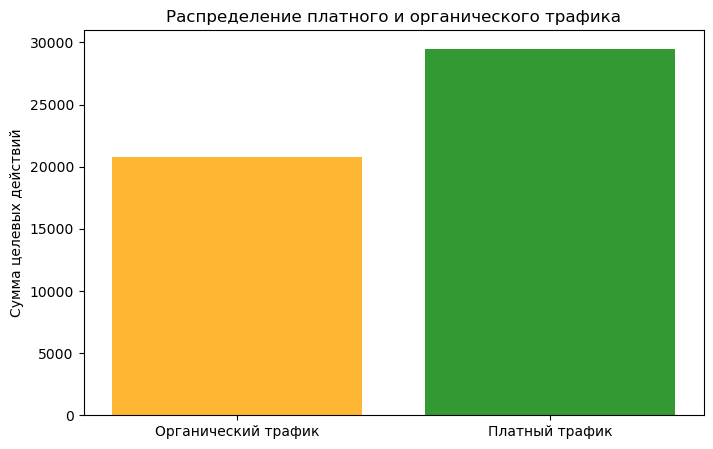

In [170]:
organic_traffic = ['organic', 'referral', '(none)']
is_organic = targets_df['utm_medium'].isin(organic_traffic).astype(int)

plt_build(is_organic, ['Органический трафик', 'Платный трафик'], 'Распределение платного и органического трафика')

Платный трафик превышает органический. H0 отвергнута

### Трафик с мобильных устройств не отличается от трафика с десктопных устройств с точки зрения CR (Conversion Rate) в целевые события.

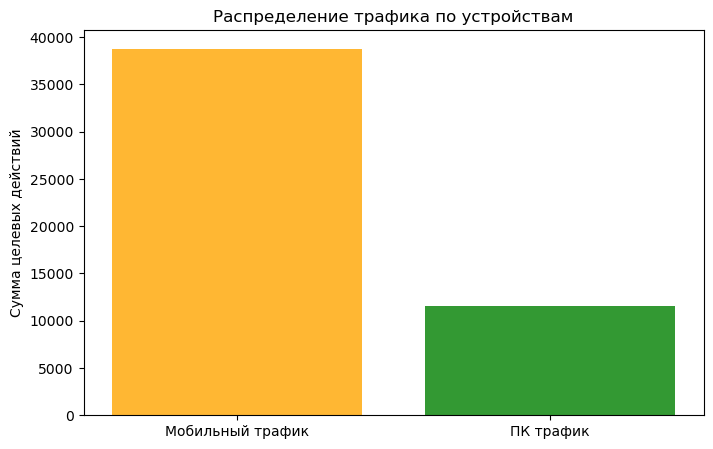

In [171]:
mobile_trafic = ['mobile', 'tablet']
is_mobile = targets_df['device_category'].isin(mobile_trafic).astype(int)

plt_build(is_mobile, ['Мобильный трафик', 'ПК трафик'], 'Распределение трафика по устройствам')

Мобильный трафик превышает ПК трафик. H0 отвергнута

### Трафик из городов присутствия (Москва и область, Санкт-Петербург) не отличается от трафика из иных регионов с точки зрения CR (Conversion Rate) в целевые события.

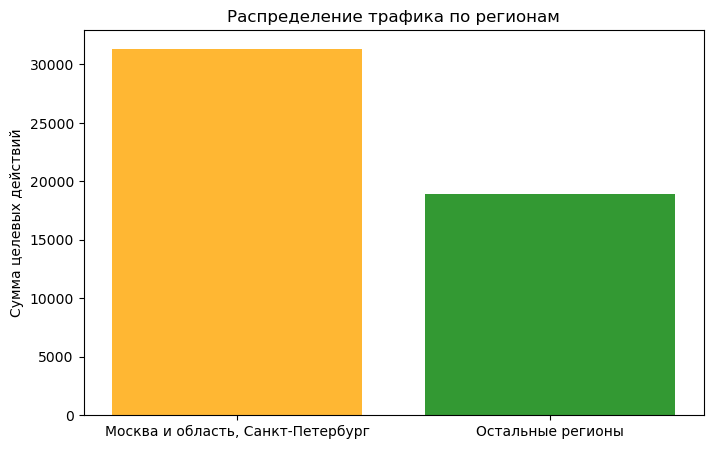

In [172]:
presence_sity = ['Moscow', 'Saint Petersburg', 'Balashikha', 'Domodedovo']
is_presence_sity = targets_df['geo_city'].isin(presence_sity).astype(int)

plt_build(is_presence_sity, ['Москва и область, Санкт-Петербург', 'Остальные регионы'], 'Распределение трафика по регионам')

Трафик из городов присутствия превышает трафик из регионов. H0 отвергнута

# 4. Аnswers to questions

### Из каких источников / кампаний / устройств / локаций к нам идёт самый целевой трафик (и с точки зрения объёма трафика, и с точки зрения CR)?

In [173]:
def figure_build(total_trafic, cr_trafic, total_title, cr_title, figure_title, tick_rotation = 45):
    fig, (general, cr) = plt.subplots(figsize=(18, 5), nrows=1, ncols=2)
    general.bar(total_trafic.index, total_trafic.values)
    general.set_title(total_title)
    general.tick_params(axis='x', rotation=tick_rotation)
    general.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', ' ')))

    cr.bar(cr_trafic.index, cr_trafic.values)
    cr.set_title(cr_title)
    cr.tick_params(axis='x', rotation=tick_rotation)
    cr.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', ' ')))

    fig.suptitle(figure_title)
    plt.show()

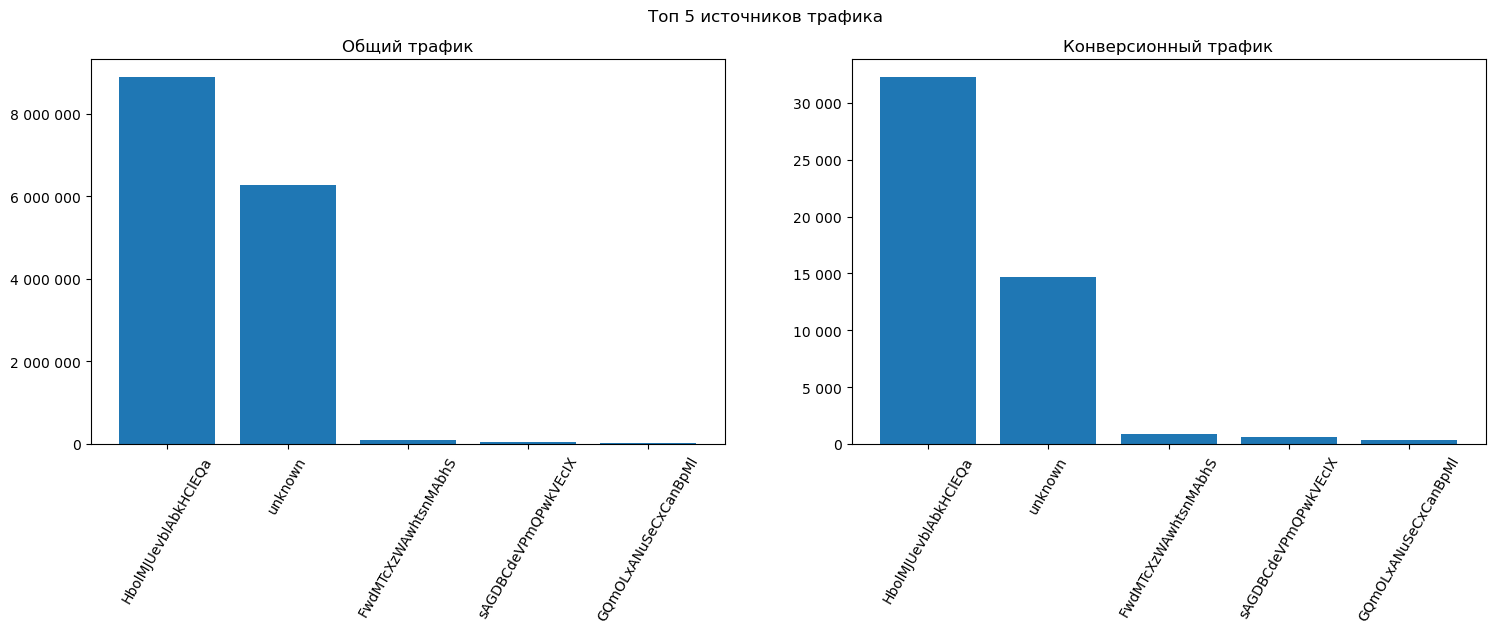

In [174]:
total_sources = prep_hits_df['hit_referer'].value_counts().head(5)
cr_sources = targets_df['hit_referer'].value_counts().head(5)

figure_build(total_sources, cr_sources, 'Общий трафик', 'Конверсионный трафик', 'Топ 5 источников трафика', 60)

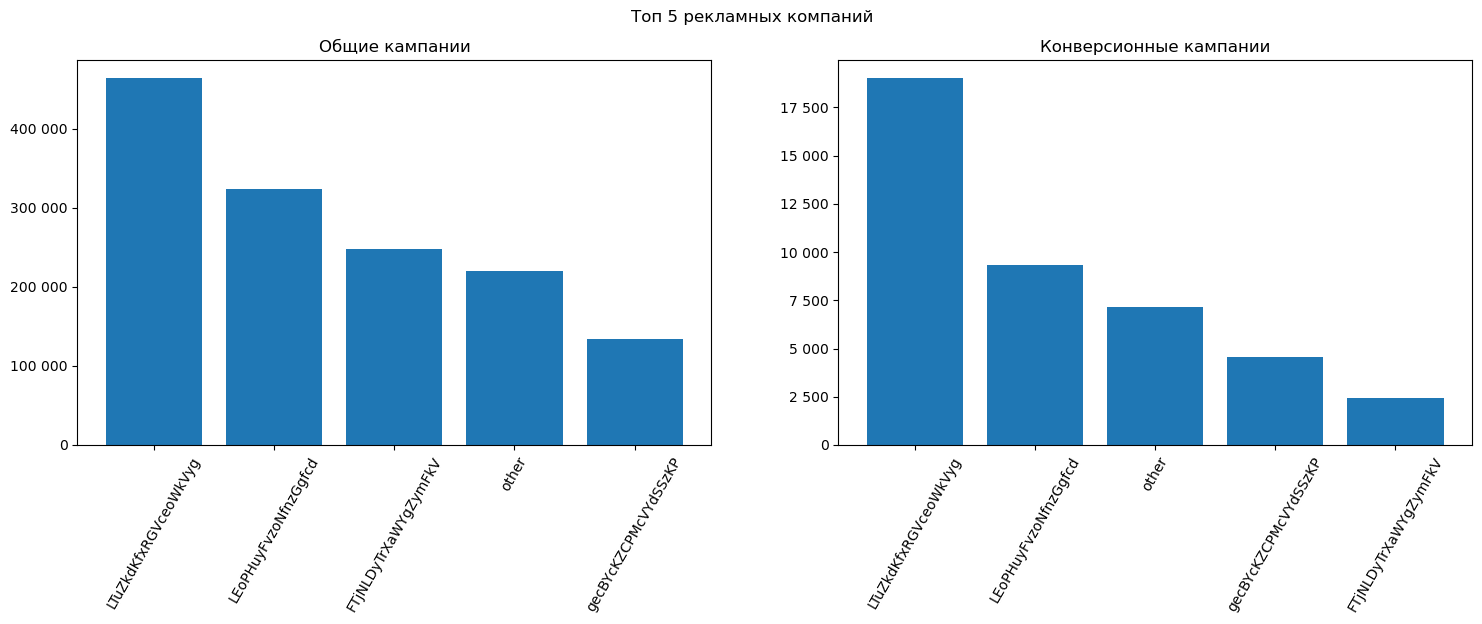

In [175]:
total_campain = prep_session_df['utm_campaign'].value_counts().head(5)
cr_campain = targets_df['utm_campaign'].value_counts().head(5)

figure_build(total_campain, cr_campain, 'Общие кампании', 'Конверсионные кампании', 'Топ 5 рекламных компаний', 60)

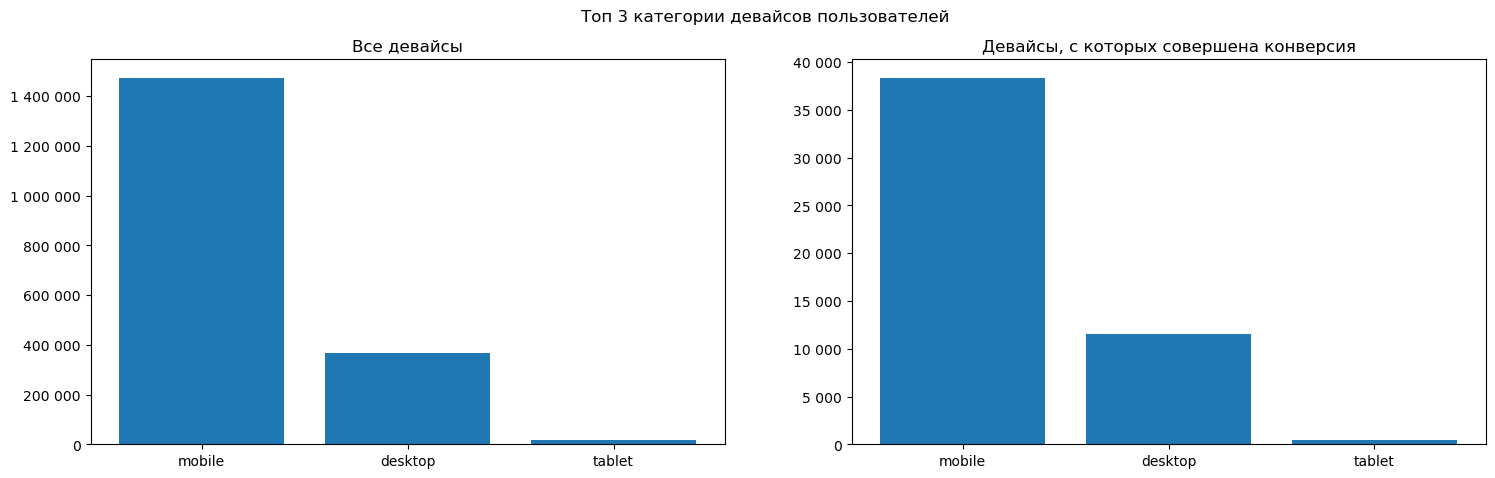

In [176]:
total_device_category = prep_session_df['device_category'].value_counts().head(5)
cr_device_category = targets_df['device_category'].value_counts().head(5)

figure_build(total_device_category, cr_device_category, 'Все девайсы', 'Девайсы, с которых совершена конверсия', 'Топ 3 категории девайсов пользователей', 0)

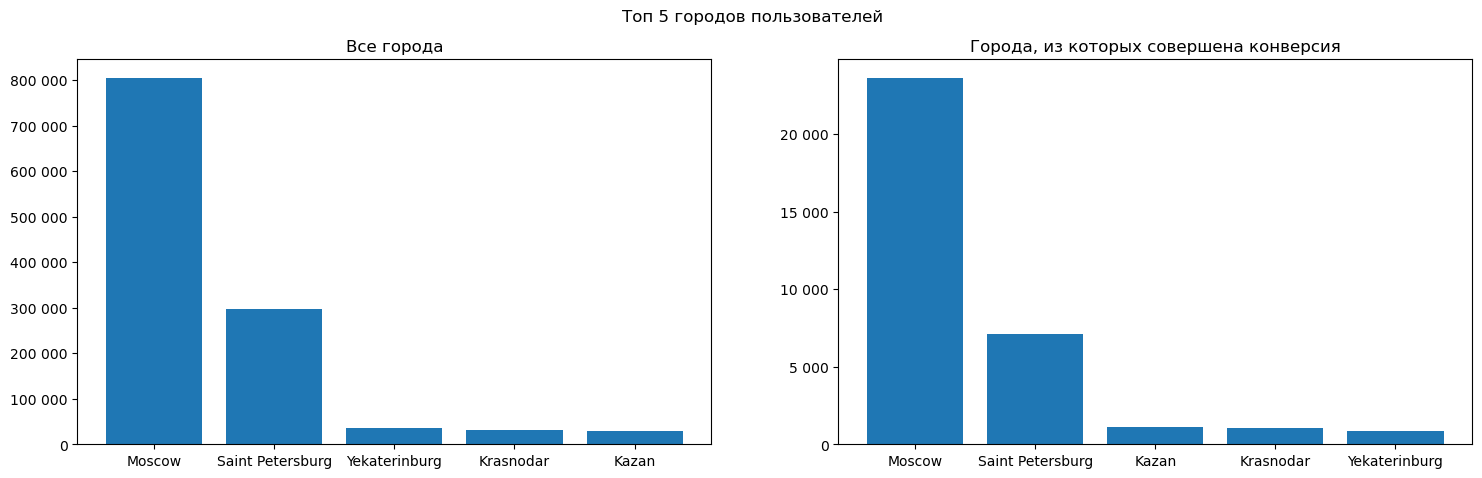

In [177]:
total_location = prep_session_df['geo_city'].value_counts().drop('(not set)').head(5)
cr_location = targets_df['geo_city'].value_counts().drop('(not set)').head(5)

figure_build(total_location, cr_location, 'Все города', 'Города, из которых совершена конверсия', 'Топ 5 городов пользователей', 0)

Примечание. Значительная часть трафика приходит из неизвестного или неотслеживаемого источника

### Какие авто пользуются наибольшим спросом? У каких авто самый лучший показатель CR (Conversion Rate) в целевые события?

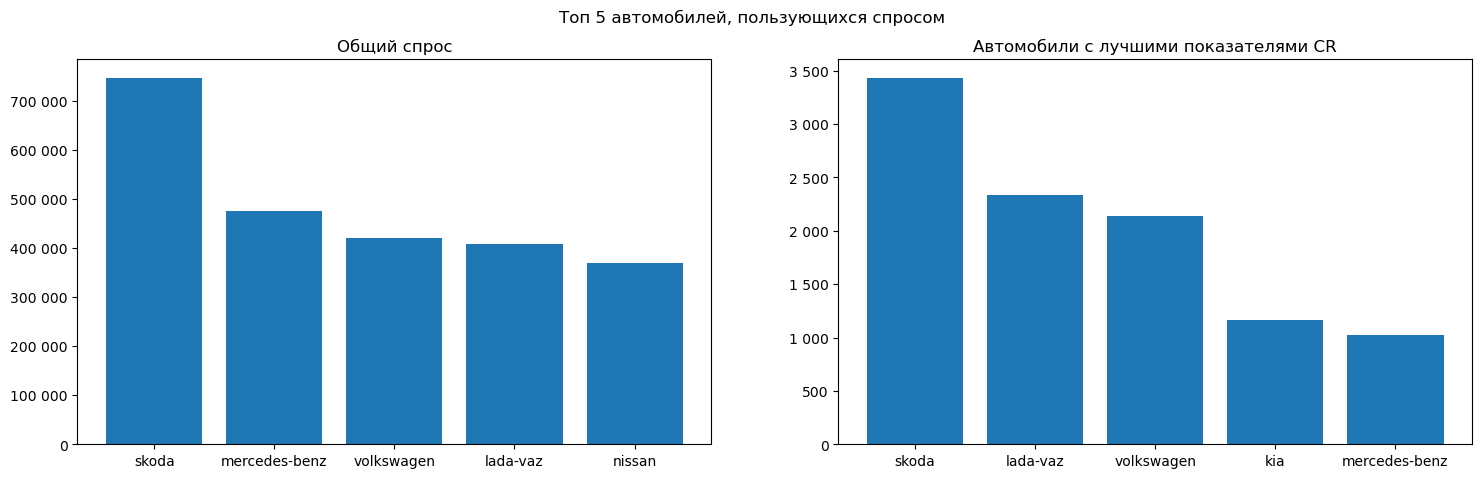

In [178]:
total_car_brand = prep_hits_df['car_brand'].value_counts().head(5)
cr_car_brand = targets_df['car_brand'].value_counts().head(5)

figure_build(total_car_brand, cr_car_brand, 'Общий спрос', 'Автомобили с лучшими показателями CR', 'Топ 5 автомобилей, пользующихся спросом', 0)

### Стоит ли нам увеличивать своё присутствие в соцсетях и давать там больше рекламы?

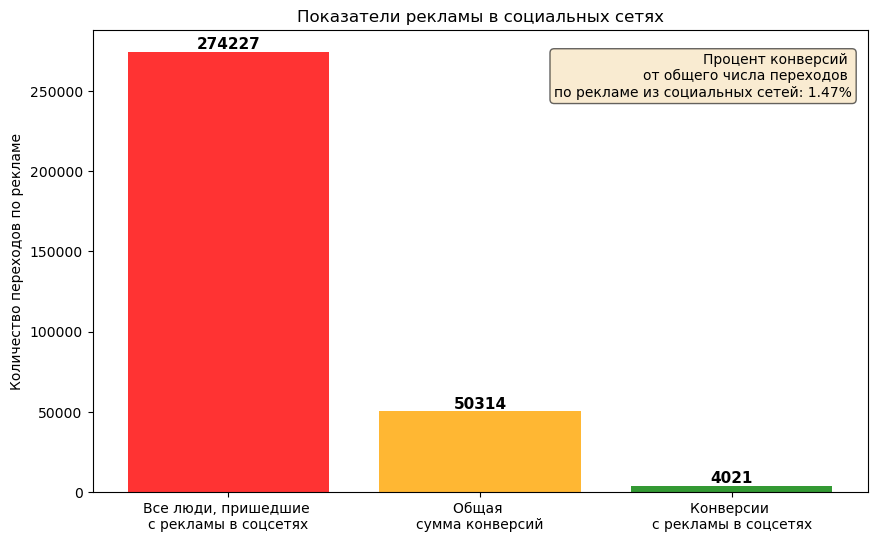

In [179]:
social_media_utm = ['QxAxdyPLuQMEcrdZWdWb',
                    'MvfHsxITijuriZxsqZqt',
                    'ISrKoXQCxqqYvAZICvjs',
                    'IZEXUFLARCUMynmHNBGo',
                    'PlbkrSYoHuZBWfYjYnfw',
                    'gVRrcxiDQubJiljoTbGm']


sm_from_general = len(session_df[session_df['utm_source'].isin(social_media_utm)])
sm_from_target = len(targets_df[targets_df['utm_source'].isin(social_media_utm)])
all_targets_sum = len(targets_df)
indicators_list = [sm_from_general, sm_from_target, all_targets_sum]


sm_figure, ax = plt.subplots(figsize=(10, 6))
sm_bars = plt.bar(['Все люди, пришедшие \nс рекламы в соцсетях', 'Общая \nсумма конверсий', 'Конверсии \nс рекламы в соцсетях'], 
        [sm_from_general, all_targets_sum, sm_from_target], 
        color=['red', 'orange', 'green'], 
        alpha=0.8)

conversion_info = f'Процент конверсий \nот общего числа переходов \nпо рекламе из социальных сетей: {round(sm_from_target / sm_from_general * 100, 2)}%'

ax.bar_label(sm_bars, fontsize=11, fontweight='bold')
ax.text(0.98, 
        0.85, 
        conversion_info, 
        transform=ax.transAxes, 
        fontsize=10, 
        verticalalignment='bottom', 
        horizontalalignment='right', 
        bbox={'boxstyle': 'round', 'facecolor': 'wheat', 'alpha': 0.6})

plt.ylabel('Количество переходов по рекламе')
plt.title('Показатели рекламы в социальных сетях')
plt.show()

Увеличивать присутствие в социальных сетях не стоит. Из социальных сетей и так идет очень много трафка, но всего 1.47% из него переходит в конверсии. Вместо увеличения присутствия стоит пересмотреть рекламные компании